In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sol_numerica_avancada(f, m):
    # Resolve $u'' = f(x)$ com $u'(0)=\pi$ e $u(1)=0$ por diferenças finitas (diferença avançada na CC de Neumann)

    h = 1 / (m+1)
    x = np.linspace(0, 1-h, m+1)

    ### Monta a matriz $A_a$ e o vetor $\vec{f}_a$
    A_a = np.diag(np.ones(m), k=-1) - 2*np.diag(np.ones(m+1)) + np.diag(np.ones(m), k=1)
    A_a[0, :] = 0
    A_a[0, 0] = -h
    A_a[0, 1] = h
    A_a = A_a / h**2

    f_vec_a = f(x)
    f_vec_a[0] = np.pi

    ### Resolve o sistema com o numpy (decomposição LU com pivotamento parcial)
    u_h_vec_a = np.linalg.solve(A_a, f_vec_a)

    return u_h_vec_a

def sol_numerica_centrada(f, m):
    # Resolve $u'' = f(x)$ com $u'(0)=\pi$ e $u(1)=0$ por diferenças finitas (diferença centrada na CC de Neumann)

    h = 1 / (m+1)
    x = np.linspace(0, 1-h, m+1)

    ### Monta a matriz $A_c$ e o vetor $\vec{f}_c$
    A_c = np.diag(np.ones(m), k=-1) - 2*np.diag(np.ones(m+1)) + np.diag(np.ones(m), k=1)
    A_c[0, :] = 0
    A_c[0, 0] = -1
    A_c[0, 1] = 1
    A_c = A_c / h**2

    f_vec_c = f(x)
    f_vec_c[0] = f(0)/2 + np.pi / h

    ### Resolve o sistema com o numpy (decomposição LU com pivotamento parcial)
    u_h_vec_c = np.linalg.solve(A_c, f_vec_c)

    return u_h_vec_c

def norma_do_erro(q, u_exata, u_h_vec):
    # Calcula a $q$-norma do erro

    m = len(u_h_vec) - 1
    h = 1 / (m+1)
    x = np.linspace(0, 1-h, m+1)
    erro_vec = u_h_vec - u_exata(x)

    ### Se for a $\infty$-norma então retorna o máximo dos erros ponto a ponto
    if q == 'inf':
        return np.max(np.abs(erro_vec))

    return (h * np.sum(np.abs(erro_vec)**q))**(1/q)

In [2]:
### Termos de fonte e soluções exatas das equações
def u_exata_1(x):
    return np.sin(np.pi*x)

def u_exata_2(x):
    return np.sin(np.pi*x) + np.cos(np.pi*x/2)

def f_1(x):
    return -np.pi**2 * np.sin(np.pi*x)

def f_2(x):
    return -np.pi**2 * (np.sin(np.pi*x) + 1/4 * np.cos(np.pi*x/2))

In [3]:
fs = [f_1, f_2]
sols_exatas = [u_exata_1, u_exata_2]
pontos_internos = [2**3, 2**4, 2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12]
qs = [1, 2, 'inf']
normas_q_todas = []

for metodo in [sol_numerica_avancada, sol_numerica_centrada]:
    for f, u_exata in zip(fs, sols_exatas):
        normas_q = []

        ### Faz os estudos de convergência e armazena em normas_q
        for q in qs:
            normas = []
            for m in pontos_internos:
                solucao = metodo(f, m)
                normas.append(norma_do_erro(q, u_exata, solucao))
            normas_q.append(normas)

        normas_q_todas.append(normas_q)

In [4]:
### Monta a tabela organizada da análise de convergência
normas_q_avancada_f1 = normas_q_todas[0]
normas_q_avancada_f2 = normas_q_todas[1]
normas_q_centrada_f1 = normas_q_todas[2]
normas_q_centrada_f2 = normas_q_todas[3]

### Primeiro a tabela da diferença avançada
print('='*97)
print(f"{'Método: Diferença Avançada na CC':^99}")
print('='*97)
print('-'*97)
print(f" {'':<4} | {'f_1':^43} | {'f_2':^43}")
print(f" {'m':<4} | {'1-norma':^10} {'2-norma':^10} {'inf-norma':^10} {'p_inf':^10} | {'1-norma':^10} {'2-norma':^10} {'inf-norma':^10} {'p_inf':^10}")
print('-'*97)

for i in range(len(pontos_internos)):
    m = pontos_internos[i]

    e1_1 = normas_q_avancada_f1[0][i]
    e1_2 = normas_q_avancada_f1[1][i]
    e1_inf = normas_q_avancada_f1[2][i]

    e2_1 = normas_q_avancada_f2[0][i]
    e2_2 = normas_q_avancada_f2[1][i]
    e2_inf = normas_q_avancada_f2[2][i]

    if i == 0:
        print(f" {m:<4} | {e1_1:^10.2e} {e1_2:^10.2e} {e1_inf:^10.2e} {'-':^10} | {e2_1:^10.2e} {e2_2:^10.2e} {e2_inf:^10.2e} {'-':^10}")
        continue

    p1_inf = np.log2(normas_q_avancada_f1[2][i-1] / normas_q_avancada_f1[2][i])
    p2_inf = np.log2(normas_q_avancada_f2[2][i-1] / normas_q_avancada_f2[2][i])

    print(f" {m:<4} | {e1_1:^10.2e} {e1_2:^10.2e} {e1_inf:^10.2e} {p1_inf:^10.4f} | {e2_1:^10.2e} {e2_2:^10.2e} {e2_inf:^10.2e} {p2_inf:^10.4f}")
print('-'*97)


### Agora a tabela da diferença centrada
print('\n' + '='*97)
print(f"{'Método: Diferença Centrada na CC':^97}")
print('='*97)
print('-'*97)
print(f" {'':<4} | {'f_1':^43} | {'f_2':^43}")
print(f" {'m':<4} | {'1-norma':^10} {'2-norma':^10} {'inf-norma':^10} {'p_inf':^10} | {'1-norma':^10} {'2-norma':^10} {'inf-norma':^10} {'p_inf':^10}")
print('-'*97)

for i in range(len(pontos_internos)):
    m = pontos_internos[i]

    e1_1 = normas_q_centrada_f1[0][i]
    e1_2 = normas_q_centrada_f1[1][i]
    e1_inf = normas_q_centrada_f1[2][i]

    e2_1 = normas_q_centrada_f2[0][i]
    e2_2 = normas_q_centrada_f2[1][i]
    e2_inf = normas_q_centrada_f2[2][i]

    if i == 0:
        print(f" {m:<4} | {e1_1:^10.2e} {e1_2:^10.2e} {e1_inf:^10.2e} {'-':^10} | {e2_1:^10.2e} {e2_2:^10.2e} {e2_inf:^10.2e} {'-':^10}")
        continue

    p1_inf = np.log2(normas_q_centrada_f1[2][i-1] / normas_q_centrada_f1[2][i])
    p2_inf = np.log2(normas_q_centrada_f2[2][i-1] / normas_q_centrada_f2[2][i])

    print(f" {m:<4} | {e1_1:^10.2e} {e1_2:^10.2e} {e1_inf:^10.2e} {p1_inf:^10.4f} | {e2_1:^10.2e} {e2_2:^10.2e} {e2_inf:^10.2e} {p2_inf:^10.4f}")
print('-'*97)

                                 Método: Diferença Avançada na CC                                  
-------------------------------------------------------------------------------------------------
      |                     f_1                     |                     f_2                    
 m    |  1-norma    2-norma   inf-norma    p_inf    |  1-norma    2-norma   inf-norma    p_inf   
-------------------------------------------------------------------------------------------------
 8    |  1.13e-02   1.57e-02   3.20e-02      -      |  8.57e-02   9.88e-02   1.66e-01      -     
 16   |  2.93e-03   4.12e-03   8.95e-03    1.8372   |  4.09e-02   4.71e-02   8.08e-02    1.0430  
 32   |  7.42e-04   1.05e-03   2.37e-03    1.9145   |  1.99e-02   2.29e-02   3.96e-02    1.0301  
 64   |  1.87e-04   2.66e-04   6.12e-04    1.9561   |  9.79e-03   1.13e-02   1.95e-02    1.0177  
 128  |  4.68e-05   6.68e-05   1.55e-04    1.9778   |  4.86e-03   5.61e-03   9.71e-03    1.0096  
 256  |  1.17e-05 

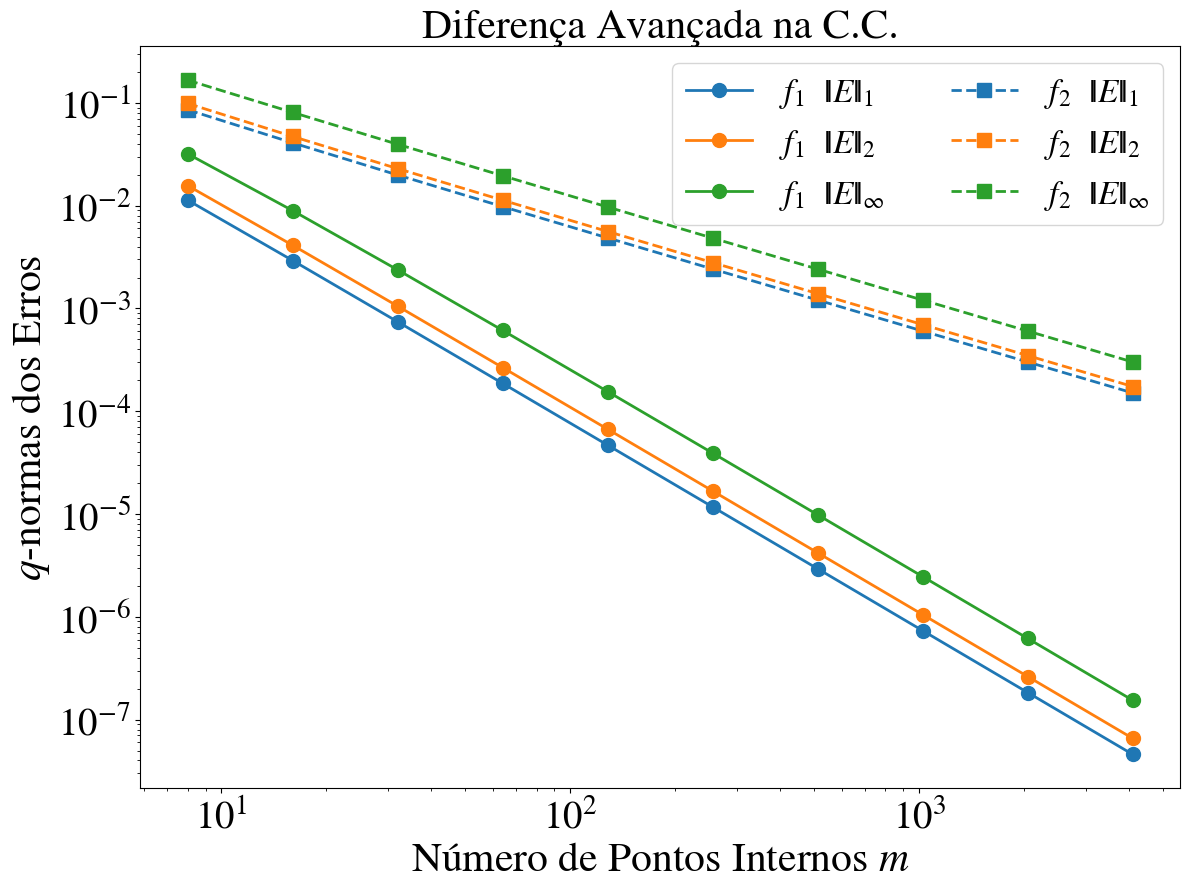

In [5]:
### Plota as normas dos erros em função de m das diferenças avançadas
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

cores = ['#1f77b4', '#ff7f0e', '#2ca02c']
nomes_q = ['1', '2', r'\infty']

fig, ax = plt.subplots(figsize=(12,9))

for i in range(3):
    ax.loglog(pontos_internos, normas_q_avancada_f1[i], marker='o', linestyle='-', color=cores[i],
              label=rf'$f_1$  $|\!|E|\!|_{{{nomes_q[i]}}}$', ms=10, linewidth=2)

for i in range(3):
    ax.loglog(pontos_internos, normas_q_avancada_f2[i], marker='s', linestyle='--', color=cores[i],
              label=rf'$f_2$  $|\!|E|\!|_{{{nomes_q[i]}}}$', ms=10, linewidth=2)

ax.tick_params(axis='both', which='major', labelsize=28)
ax.set_title('Diferença Avançada na C.C.', fontsize=30)
ax.set_xlabel(r'Número de Pontos Internos $m$', fontsize=30)
ax.set_ylabel(r'$q$-normas dos Erros', fontsize=30)

ax.legend(fontsize=24, ncol=2)
plt.tight_layout()
plt.savefig('normas_erros_avancada.svg')
plt.show()

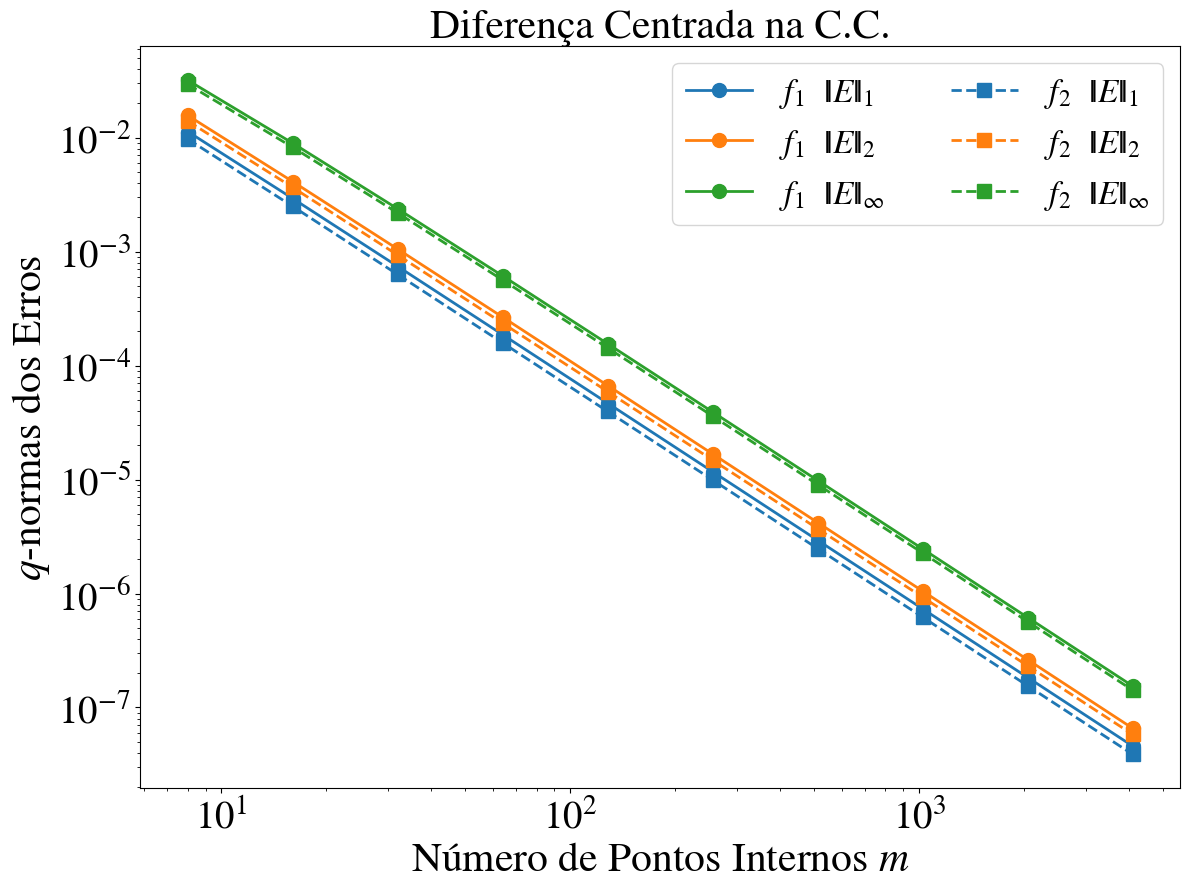

In [6]:
### Plota as normas dos erros em função de m das diferenças centradas
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

cores = ['#1f77b4', '#ff7f0e', '#2ca02c']
nomes_q = ['1', '2', r'\infty']

fig, ax = plt.subplots(figsize=(12,9))

for i in range(3):
    ax.loglog(pontos_internos, normas_q_centrada_f1[i], marker='o', linestyle='-', color=cores[i],
              label=rf'$f_1$  $|\!|E|\!|_{{{nomes_q[i]}}}$', ms=10, linewidth=2)

for i in range(3):
    ax.loglog(pontos_internos, normas_q_centrada_f2[i], marker='s', linestyle='--', color=cores[i],
              label=rf'$f_2$  $|\!|E|\!|_{{{nomes_q[i]}}}$', ms=10, linewidth=2)

ax.tick_params(axis='both', which='major', labelsize=28)
ax.set_title('Diferença Centrada na C.C.', fontsize=30)
ax.set_xlabel(r'Número de Pontos Internos $m$', fontsize=30)
ax.set_ylabel(r'$q$-normas dos Erros', fontsize=30)

ax.legend(fontsize=24, ncol=2)
plt.tight_layout()
plt.savefig('normas_erros_centrada.svg')
plt.show()